# Time-Series Forecasting with RNN, LSTM, and GRU

Sequence models are also widely used for time-series forecasting. In this notebook, recurrent neural networks are applied to the **Jena Climate** dataset.

The goal is to use recent weather measurements to predict a future temperature value.

The experiment compares:

1. Simple RNN
2. LSTM
3. GRU

using the same input window, prediction horizon, optimizer, and evaluation metric.


## Import Libraries


In [ ]:
import os
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Download the Jena Climate Dataset

The Jena Climate dataset contains weather measurements collected every 10 minutes. To reduce sequence length and computation, every sixth row is retained, producing approximately hourly observations.


In [ ]:
zip_path = tf.keras.utils.get_file(
    origin=(
        "https://storage.googleapis.com/"
        "tensorflow/tf-keras-datasets/"
        "jena_climate_2009_2016.csv.zip"
    ),
    fname="jena_climate_2009_2016.csv.zip",
    extract=False,
)

extract_dir = os.path.dirname(
    zip_path
)

with zipfile.ZipFile(
    zip_path,
    "r",
) as z:
    z.extractall(
        extract_dir
    )

csv_path = os.path.join(
    extract_dir,
    "jena_climate_2009_2016.csv",
)

df = pd.read_csv(
    csv_path
)

print(
    "Dataset shape:",
    df.shape,
)

df.head()


Dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## Inspect the Available Measurements


In [ ]:
print(
    df.columns.tolist()
)

print(
    df.dtypes
)


['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']
Date Time           object
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object


## Create an Hourly Dataset

The original data are recorded every 10 minutes. Selecting every sixth row gives a sequence with approximately one observation per hour.


In [ ]:
hourly = df.iloc[
    ::6
].reset_index(
    drop=True
)

print(
    "Hourly dataset shape:",
    hourly.shape,
)

hourly.head()


Hourly dataset shape: (70092, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2,01.01.2009 02:10:00,996.63,-8.85,264.57,-9.70,93.5,3.12,2.92,0.20,1.82,2.93,1312.11,0.16,0.50,158.3
3,01.01.2009 03:10:00,996.87,-8.84,264.56,-9.69,93.5,3.13,2.92,0.20,1.83,2.93,1312.37,0.07,0.25,129.3
4,01.01.2009 04:10:00,997.05,-9.23,264.15,-10.25,92.2,3.03,2.79,0.24,1.74,2.80,1314.62,0.10,0.38,203.9


## Plot Temperature over Time


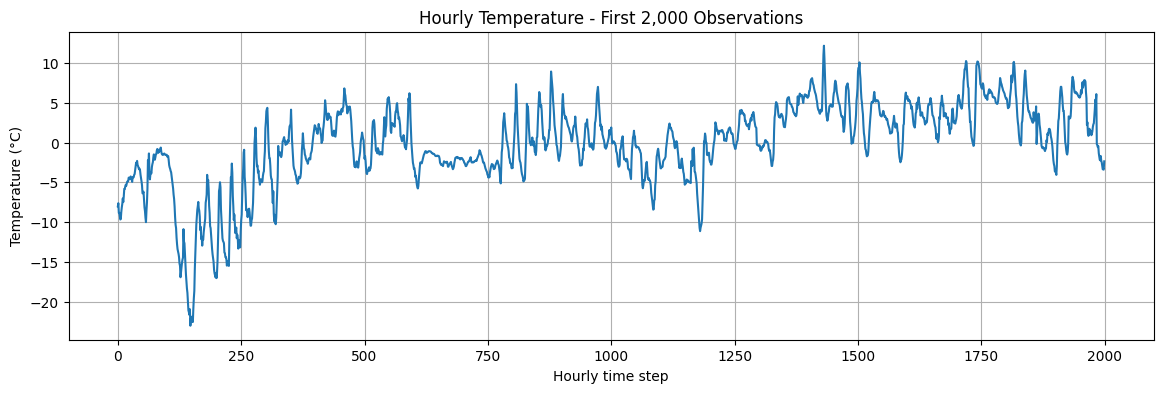

In [ ]:
plt.figure(
    figsize=(14, 4)
)

plt.plot(
    hourly["T (degC)"].values[:2000]
)

plt.title(
    "Hourly Temperature - First 2,000 Observations"
)
plt.xlabel(
    "Hourly time step"
)
plt.ylabel(
    "Temperature (°C)"
)
plt.grid(True)
plt.show()


## Select Forecasting Features

A compact multivariate input is used:

- temperature,
- atmospheric pressure,
- relative humidity,
- wind speed.

The target is future temperature.


In [ ]:
feature_names = [
    "T (degC)",
    "p (mbar)",
    "rh (%)",
    "wv (m/s)",
]

features = hourly[
    feature_names
].astype(
    "float32"
).values

target = hourly[
    "T (degC)"
].astype(
    "float32"
).values

print(
    "Feature matrix:",
    features.shape,
)

print(
    "Target vector:",
    target.shape,
)


Feature matrix: (70092, 4)
Target vector: (70092,)


## Chronological Train, Validation, and Test Split

Time-series data should not be randomly shuffled before splitting because future observations must not leak into the past.

The dataset is divided chronologically into:

- 70% training
- 15% validation
- 15% test


In [ ]:
n = len(features)

train_end = int(
    0.70 * n
)

val_end = int(
    0.85 * n
)

train_features = features[
    :train_end
]

val_features = features[
    train_end:val_end
]

test_features = features[
    val_end:
]

train_target = target[
    :train_end
]

val_target = target[
    train_end:val_end
]

test_target = target[
    val_end:
]

print(
    "Train:",
    train_features.shape
)
print(
    "Validation:",
    val_features.shape
)
print(
    "Test:",
    test_features.shape
)


Train: (49064, 4)
Validation: (10514, 4)
Test: (10514, 4)


## Standardize Using Training Statistics

The mean and standard deviation are calculated from the training subset only. The same values are then applied to validation and test data.


In [ ]:
train_mean = train_features.mean(
    axis=0
)

train_std = train_features.std(
    axis=0
)

train_features = (
    train_features
    - train_mean
) / train_std

val_features = (
    val_features
    - train_mean
) / train_std

test_features = (
    test_features
    - train_mean
) / train_std

target_mean = train_target.mean()
target_std = train_target.std()

train_target_scaled = (
    train_target
    - target_mean
) / target_std

val_target_scaled = (
    val_target
    - target_mean
) / target_std

test_target_scaled = (
    test_target
    - target_mean
) / target_std

print(
    "Training feature mean:",
    np.round(
        train_features.mean(
            axis=0
        ),
        4,
    )
)


Training feature mean: [-0. -0. -0.  0.]


## Create Input Sequences

Each input sequence contains the previous **120 hours** of weather observations.

The target is the temperature **24 hours after the end of the input window**.

Therefore:

```text
120 hours of history
        ↓
RNN / LSTM / GRU
        ↓
temperature 24 hours later
```


In [ ]:
window_size = 120
forecast_horizon = 24


def create_sequences(
    X,
    y,
    window_size,
    forecast_horizon,
):
    X_seq = []
    y_seq = []

    last_start = (
        len(X)
        - window_size
        - forecast_horizon
        + 1
    )

    for start in range(
        last_start
    ):
        end = (
            start
            + window_size
        )

        target_index = (
            end
            + forecast_horizon
            - 1
        )

        X_seq.append(
            X[start:end]
        )

        y_seq.append(
            y[target_index]
        )

    return (
        np.asarray(
            X_seq,
            dtype="float32",
        ),
        np.asarray(
            y_seq,
            dtype="float32",
        ),
    )


X_train_seq, y_train_seq = create_sequences(
    train_features,
    train_target_scaled,
    window_size,
    forecast_horizon,
)

X_val_seq, y_val_seq = create_sequences(
    val_features,
    val_target_scaled,
    window_size,
    forecast_horizon,
)

X_test_seq, y_test_seq = create_sequences(
    test_features,
    test_target_scaled,
    window_size,
    forecast_horizon,
)

print(
    "X_train_seq:",
    X_train_seq.shape,
)
print(
    "y_train_seq:",
    y_train_seq.shape,
)
print(
    "X_val_seq:",
    X_val_seq.shape,
)
print(
    "X_test_seq:",
    X_test_seq.shape,
)


X_train_seq: (48921, 120, 4)
y_train_seq: (48921,)
X_val_seq: (10371, 120, 4)
X_test_seq: (10371, 120, 4)


## Inspect One Forecasting Sequence


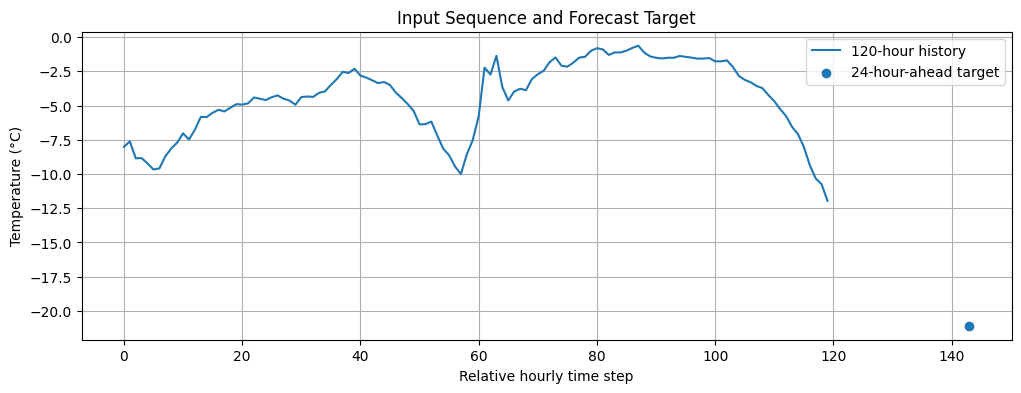

In [ ]:
sequence_id = 0

temperature_feature_index = feature_names.index(
    "T (degC)"
)

historical_temperature = (
    X_train_seq[
        sequence_id,
        :,
        temperature_feature_index,
    ]
    * train_std[
        temperature_feature_index
    ]
    + train_mean[
        temperature_feature_index
    ]
)

future_temperature = (
    y_train_seq[
        sequence_id
    ]
    * target_std
    + target_mean
)

plt.figure(
    figsize=(12, 4)
)

plt.plot(
    historical_temperature,
    label="120-hour history",
)

plt.scatter(
    window_size - 1 + forecast_horizon,
    future_temperature,
    label="24-hour-ahead target",
)

plt.xlabel(
    "Relative hourly time step"
)
plt.ylabel(
    "Temperature (°C)"
)
plt.title(
    "Input Sequence and Forecast Target"
)
plt.grid(True)
plt.legend()
plt.show()


## Training Settings


In [ ]:
hidden_units = 64
epochs = 100
batch_size = 128


def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1,
        ),
    ]


## What Do the Sequence Models Learn from the Climate Data?

The forecasting models are not given a fixed formula describing how temperature should change. They learn temporal relationships directly from historical sequences.

From each 120-hour input window, the recurrent models can learn patterns such as:

- how recent temperature values influence future temperature,
- short-term warming and cooling trends,
- delayed relationships between humidity, pressure, wind speed, and temperature,
- recurring temporal patterns,
- and which parts of the 120-hour history are most useful for predicting temperature 24 hours ahead.

The training objective compares the predicted future temperature with the actual future temperature. Backpropagation adjusts the recurrent and output-layer weights so that forecasting error decreases.

RNN, LSTM, and GRU receive the same information. Their main difference is **how they store, update, and forget information while moving through the 120-hour sequence**.


# 1. Simple RNN Forecasting Model

A Simple RNN processes the 120-hour history one time step at a time. At each hour, it combines the current weather measurements with the hidden state created from previous hours.

### What does it learn here?

The RNN learns recurrent weights that summarize recent temperature, pressure, humidity, and wind information into a hidden representation. That final representation is mapped to the predicted temperature 24 hours ahead.

Because the same recurrent transformation is repeatedly applied across 120 time steps, a Simple RNN may have difficulty retaining useful information from the earliest hours of a long input window.


In [ ]:
rnn_model = Sequential(
    [
        Input(
            shape=(
                window_size,
                len(feature_names),
            )
        ),
        SimpleRNN(
            hidden_units,
            activation="tanh",
        ),
        Dense(
            1
        ),
    ],
    name="simple_rnn_forecaster",
)

rnn_model.summary()

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["mae"],
)


Model: "simple_rnn_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Simple RNN


In [ ]:
start_train = time.time()

rnn_history = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(
        X_val_seq,
        y_val_seq,
    ),
    callbacks=get_callbacks(),
    verbose=1,
)

end_train = time.time()

print(
    "Training time:",
    f"{end_train - start_train:.2f} seconds",
)


Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - loss: 0.1538 - mae: 0.3037 - val_loss: 0.1392 - val_mae: 0.2885 - learning_rate: 0.0010
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.1346 - mae: 0.2862 - val_loss: 0.1359 - val_mae: 0.2847 - learning_rate: 0.0010
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.1306 - mae: 0.2818 - val_loss: 0.1376 - val_mae: 0.2867 - learning_rate: 0.0010
Epoch 4/100
382/383 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1287 - mae: 0.2798
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.1275 - mae: 0.2785 - val_loss: 0.1362 - val_mae: 0.2855 - learning_rate: 0.0010
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - loss: 0.1231 - mae: 0.2736 - val_loss: 0.1340 - val_mae: 0.2822 - learning_rate: 5.0000e-04
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.1218 - mae: 0.2722 - val_loss: 0.1333 - val_mae: 0.2816 - l

# 2. LSTM Forecasting Model

The LSTM processes the same 120-hour weather history but uses a cell state together with forget, input, and output gates.

### What does it learn here?

The LSTM learns which past weather information should remain in memory, which information should be discarded, and which new observations should update the memory. This allows the model to preserve useful relationships across longer portions of the 120-hour history.

For example, the learned gates may retain a longer temperature trend while giving less importance to short-lived fluctuations that do not help the 24-hour-ahead forecast.


In [ ]:
lstm_model = Sequential(
    [
        Input(
            shape=(
                window_size,
                len(feature_names),
            )
        ),
        LSTM(
            hidden_units
        ),
        Dense(
            1
        ),
    ],
    name="lstm_forecaster",
)

lstm_model.summary()

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["mae"],
)


Model: "lstm_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,729 (69.25 KB)

 Trainable params: 17,729 (69.25 KB)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM


In [ ]:
start_train = time.time()

lstm_history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(
        X_val_seq,
        y_val_seq,
    ),
    callbacks=get_callbacks(),
    verbose=1,
)

end_train = time.time()

print(
    "Training time:",
    f"{end_train - start_train:.2f} seconds",
)


Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 59s 150ms/step - loss: 0.1802 - mae: 0.3234 - val_loss: 0.1422 - val_mae: 0.2927 - learning_rate: 0.0010
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 62s 162ms/step - loss: 0.1335 - mae: 0.2857 - val_loss: 0.1355 - val_mae: 0.2840 - learning_rate: 0.0010
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 56s 147ms/step - loss: 0.1232 - mae: 0.2739 - val_loss: 0.1321 - val_mae: 0.2805 - learning_rate: 0.0010
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 58s 151ms/step - loss: 0.1134 - mae: 0.2627 - val_loss: 0.1342 - val_mae: 0.2829 - learning_rate: 0.0010
Epoch 5/100
382/383 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.1077 - mae: 0.2564
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
383/383 ━━━━━━━━━━━━━━━━━━━━ 80s 145ms/step - loss: 0.1052 - mae: 0.2537 - val_loss: 0.1466 - val_mae: 0.2955 - learning_rate: 0.0010
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 57s 149ms/step - loss: 0.0928 - mae: 0.2381 - val_loss: 0.1522 - val_mae: 0.3007 

# 3. GRU Forecasting Model

The GRU also learns gated temporal dependencies, but it uses update and reset gates instead of the LSTM's separate cell state and three-gate structure.

### What does it learn here?

The GRU learns how much of the existing hidden state should be preserved when a new hourly observation arrives and how much of the previous information should be reset. It therefore learns a compact representation of the recent weather sequence that is useful for forecasting temperature 24 hours ahead.

The simpler gated structure can make GRU a useful alternative when similar forecasting performance can be achieved with fewer parameters than an LSTM.


In [ ]:
gru_model = Sequential(
    [
        Input(
            shape=(
                window_size,
                len(feature_names),
            )
        ),
        GRU(
            hidden_units
        ),
        Dense(
            1
        ),
    ],
    name="gru_forecaster",
)

gru_model.summary()

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="mse",
    metrics=["mae"],
)


Model: "gru_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505 (52.75 KB)

 Trainable params: 13,505 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

## Train the GRU


In [ ]:
start_train = time.time()

gru_history = gru_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(
        X_val_seq,
        y_val_seq,
    ),
    callbacks=get_callbacks(),
    verbose=1,
)

end_train = time.time()

print(
    "Training time:",
    f"{end_train - start_train:.2f} seconds",
)


Epoch 1/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 74s 188ms/step - loss: 0.1634 - mae: 0.3105 - val_loss: 0.1396 - val_mae: 0.2874 - learning_rate: 0.0010
Epoch 2/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 73s 191ms/step - loss: 0.1342 - mae: 0.2853 - val_loss: 0.1353 - val_mae: 0.2834 - learning_rate: 0.0010
Epoch 3/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 82s 191ms/step - loss: 0.1275 - mae: 0.2779 - val_loss: 0.1318 - val_mae: 0.2800 - learning_rate: 0.0010
Epoch 4/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 71s 185ms/step - loss: 0.1220 - mae: 0.2721 - val_loss: 0.1331 - val_mae: 0.2811 - learning_rate: 0.0010
Epoch 5/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.1188 - mae: 0.2690
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
383/383 ━━━━━━━━━━━━━━━━━━━━ 73s 190ms/step - loss: 0.1176 - mae: 0.2679 - val_loss: 0.1335 - val_mae: 0.2816 - learning_rate: 0.0010
Epoch 6/100
383/383 ━━━━━━━━━━━━━━━━━━━━ 70s 184ms/step - loss: 0.1128 - mae: 0.2627 - val_loss: 0.1332 - val_mae: 0.2810 

## Evaluate All Three Models


In [ ]:
def evaluate_forecaster(
    model,
    X_test_seq,
    y_test_seq,
):
    prediction_scaled = model.predict(
        X_test_seq,
        verbose=0,
    ).reshape(
        -1
    )

    prediction = (
        prediction_scaled
        * target_std
        + target_mean
    )

    actual = (
        y_test_seq
        * target_std
        + target_mean
    )

    mae = np.mean(
        np.abs(
            prediction
            - actual
        )
    )

    mse = np.mean(
        (
            prediction
            - actual
        ) ** 2
    )

    return (
        prediction,
        actual,
        mae,
        mse,
    )


rnn_pred, actual, rnn_mae, rnn_mse = evaluate_forecaster(
    rnn_model,
    X_test_seq,
    y_test_seq,
)

lstm_pred, _, lstm_mae, lstm_mse = evaluate_forecaster(
    lstm_model,
    X_test_seq,
    y_test_seq,
)

gru_pred, _, gru_mae, gru_mse = evaluate_forecaster(
    gru_model,
    X_test_seq,
    y_test_seq,
)

comparison = pd.DataFrame(
    {
        "Model": [
            "Simple RNN",
            "LSTM",
            "GRU",
        ],
        "Parameters": [
            rnn_model.count_params(),
            lstm_model.count_params(),
            gru_model.count_params(),
        ],
        "Test MAE (°C)": [
            rnn_mae,
            lstm_mae,
            gru_mae,
        ],
        "Test MSE": [
            rnn_mse,
            lstm_mse,
            gru_mse,
        ],
    }
)

comparison.sort_values(
    by="Test MAE (°C)"
).reset_index(
    drop=True
)


,Model,Parameters,Test MAE (°C),Test MSE
0,Simple RNN,4481,2.298168,8.642939
1,GRU,13505,2.315364,8.652042
2,LSTM,17729,2.322807,8.798201


## Plot Predictions from the Best Model


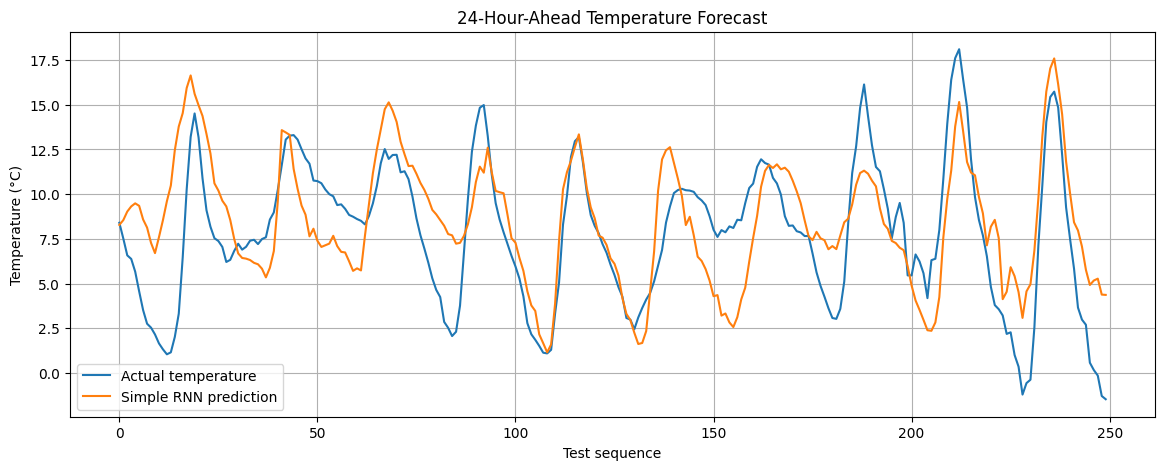

Selected model: Simple RNN


In [ ]:
model_predictions = {
    "Simple RNN": rnn_pred,
    "LSTM": lstm_pred,
    "GRU": gru_pred,
}

best_model_name = comparison.loc[
    comparison[
        "Test MAE (°C)"
    ].idxmin(),
    "Model",
]

best_prediction = model_predictions[
    best_model_name
]

plot_points = 250

plt.figure(
    figsize=(14, 5)
)

plt.plot(
    actual[:plot_points],
    label="Actual temperature",
)

plt.plot(
    best_prediction[:plot_points],
    label=(
        f"{best_model_name} prediction"
    ),
)

plt.xlabel(
    "Test sequence"
)
plt.ylabel(
    "Temperature (°C)"
)
plt.title(
    "24-Hour-Ahead Temperature Forecast"
)
plt.grid(True)
plt.legend()
plt.show()

print(
    "Selected model:",
    best_model_name,
)


## Plot Model Training Curves


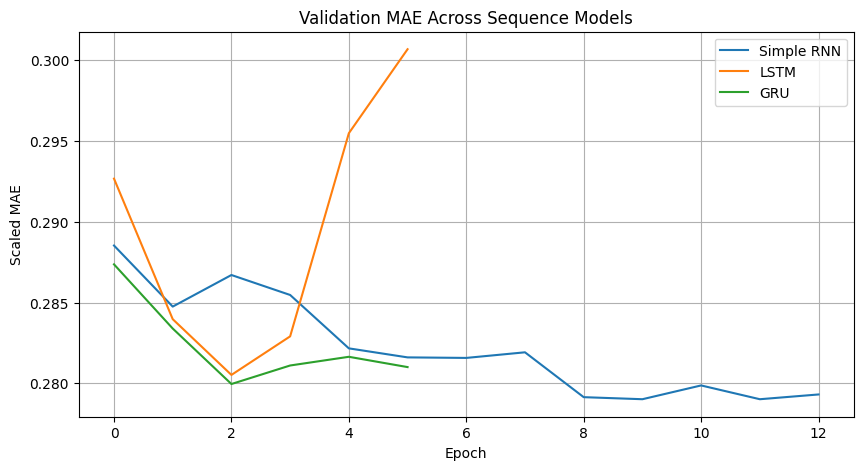

In [ ]:
histories = {
    "Simple RNN": rnn_history,
    "LSTM": lstm_history,
    "GRU": gru_history,
}

fig, ax = plt.subplots(
    figsize=(10, 5)
)

for name, history in histories.items():
    ax.plot(
        history.history["val_mae"],
        label=name,
    )

ax.set_title(
    "Validation MAE Across Sequence Models"
)
ax.set_xlabel(
    "Epoch"
)
ax.set_ylabel(
    "Scaled MAE"
)
ax.grid(True)
ax.legend()

plt.show()


## Key Takeaways

- Time-series forecasting requires chronological train, validation, and test splits.
- Sequence windows convert continuous time-series data into supervised learning examples.
- Simple RNN provides the basic recurrent baseline.
- LSTM and GRU use gating mechanisms that can retain information over longer temporal dependencies.
- Model selection should consider both forecasting error and model complexity.
- Comparing all three architectures under the same forecasting setup provides a direct view of the tradeoff between recurrent complexity and predictive performance.
